In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np
import seaborn as sns
pd.set_option('display.max_rows', None)

from numpy import asarray
from numpy import mean
from numpy import std
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from matplotlib import pyplot

import xgboost
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb

In [2]:
train = pd.read_parquet('data/train.parquet')
test = pd.read_parquet('data/val.parquet')
#val = pd.read_parquet('data/val.parquet')

In [3]:
x_rfc = ['Min_PacketSpeed',
 'Std_DataSpeed',
 'Std_DetectCount',
 'Mean_DetectCount',
 'Avg source IP count',
 'Max_DetectCount',
 'Attack ID',
 'Max_PacketSpeed',
 'total_seconds',
 'AvgPacketLen_Std',
 'Mean_DataSpeed',
 'Mean_PacketSpeed',
 'Source IP count',
 'Cos_DayOfYear',
 'Sin_DayOfYear',
 'DayOfYear',
 'AvgPacketLen_Mean',
 'Min_DataSpeed',
 'PCA_4',
 'Start Hour']

In [4]:
x_xgb = ['dist_centroid_silhouette_72',
 'Avg source IP count',
 'PCA_4',
 'dist_centroid_silhouette_61',
 'PCA_3',
 'Std_DetectCount',
 'Is_SSH',
 'dist_centroid_silhouette_54',
 'Std_DataSpeed',
 'umap_2',
 'Min_PacketSpeed',
 'Data speed',
 'Mean_DetectCount',
 'Victim IP',
 'Min_DataSpeed',
 'AvgPacketLen_Mean',
 'Attack ID',
 'PacketSpeed_Per_Second',
 'PCA_2',
 'Mean_PacketSpeed']

In [5]:
x_lgbm = ['total_seconds',
 'AvgPacketLen_Mean',
 'Avg source IP count',
 'Max_DetectCount',
 'Std_DataSpeed',
 'AvgPacketLen_Std',
 'Min_PacketSpeed',
 'Sin_DayOfYear',
 'Cos_DayOfYear',
 'Mean_DataSpeed',
 'Max_DataSpeed',
 'Mean_PacketSpeed',
 'Attack ID',
 'Max_PacketSpeed',
 'Victim IP',
 'AvgPacketLen_Per_TotalSeconds',
 'Mean_DetectCount',
 'Start Hour',
 'Min_DataSpeed',
 'DayOfYear',
 'VictimIP_Count',
 'Std_DetectCount',
 'PCA_3',
 'PCA_4',
 'PacketSpeed_Per_Second',
 'Source IP count',
 'PCA_2',
 'umap_2',
 'Is_SSH',
 'dist_centroid_silhouette_54']

In [6]:
def eval(votes, true_labels):
    # Generate the classification report
    report = classification_report(true_labels, votes)

    # Print the classification report
    print(report)
    # 1. Generate the confusion matrix
    cm = confusion_matrix(true_labels, votes)

    # 2. Visualize the confusion matrix (optional, but highly recommended)
    class_labels = np.unique(true_labels) # Get unique class labels

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

    # 3. Print the confusion matrix (textual representation)
    print(cm)

    # 1. Generate the classification report as a dictionary
    report = classification_report(true_labels, votes, output_dict=True)

    # 2. Extract the data for plotting
    classes = list(report.keys())[:-3]  # Exclude 'accuracy', 'macro avg', 'weighted avg'
    precision = [report[cls]['precision'] for cls in classes]
    recall = [report[cls]['recall'] for cls in classes]
    f1_score = [report[cls]['f1-score'] for cls in classes]

    # 3. Set up the plot
    x = np.arange(len(classes))
    width = 0.2

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width, precision, width, label='Recall')
    rects2 = ax.bar(x, recall, width, label='Precision')
    rects3 = ax.bar(x + width, f1_score, width, label='F1-score')

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Score')
    ax.set_xlabel('Classes')
    ax.set_title('Classification Report per Class')
    ax.set_xticks(x)
    ax.set_xticklabels(classes)
    ax.legend()

    ax.bar_label(rects1, fmt='%.2f', padding=3)
    ax.bar_label(rects2, fmt='%.2f', padding=3)
    ax.bar_label(rects3, fmt='%.2f', padding=3)

    fig.tight_layout()
    plt.show()

In [ ]:
import numpy as np
from sklearn.base import clone
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.svm import SVC

# 3. Define the base models and the meta-model
base_models = [
    XGBClassifier(
    objective='multi:softmax',
        num_class=3,
        booster=('dart'),
        alpha=0.6730647547618864,
        subsample=0.42803065237564275,
        colsample_bytree=0.8565965677640711,
        max_depth=5,
        eta=0.179806132737519,
        gamma=0.8114340643087419,
        grow_policy='lossguide',
        min_child_weight=5,
        eval_metric='merror',
        random_state=42
        ),
    RandomForestClassifier(n_estimators=287, max_depth=22, min_samples_split=4, min_samples_leaf=5, random_state=42, class_weight='balanced'),
    lgb.LGBMClassifier(verbose=-1, n_estimators=441, learning_rate=0.0895186049880042, num_leaves=98, max_depth=8, 
                          min_child_samples=34, subsample=0.7024962299198043, colsample_bytree=0.8199213047640314, random_state=42, is_unbalance=True),



    LogisticRegression(random_state=42, max_iter=1000)  # Meta-learner can be any classifier; Logistic Regression is a common choice
]
meta_model = LogisticRegression(random_state=42, max_iter=1000) # The final model that blends them all

X_train_list = [train[x_xgb], train[x_rfc], train[x_lgbm]]
X_test_list = [test[x_xgb], test[x_rfc], test[x_lgbm]]

# ==========================================
# MANUAL STACKING FUNCTION
# ==========================================
def manual_stacking_predict(base_models, meta_model, X_train_list, y_train, X_test_list, n_splits=5):
    X_train_list = [X.to_numpy() if hasattr(X, 'to_numpy') else X for X in X_train_list]
    X_test_list = [X.to_numpy() if hasattr(X, 'to_numpy') else X for X in X_test_list]
    y_train = y_train.to_numpy() if hasattr(y_train, 'to_numpy') else y_train


    n_samples_train = X_train_list[0].shape[0]
    n_samples_test = X_test_list[0].shape[0]
    n_classes = len(np.unique(y_train))
    n_models = len(base_models)
    
    # Initialize empty arrays to hold the "meta-features" (predicted probabilities)
    # Total columns = (number of base models) * (number of classes)
    oof_features = np.zeros((n_samples_train, n_models * n_classes))
    test_preds_folds = np.zeros((n_splits, n_samples_test, n_models * n_classes))
    
    # Use Stratified K-Fold to generate out-of-fold predictions safely
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_list[0], y_train)):
        
        # Train each base model on its specific slice of this fold's training data
        for m_idx, (model, X_base_train) in enumerate(zip(base_models, X_train_list)):
            # Clone ensures we train a fresh copy of the model configuration on every fold
            fold_model = clone(model) 
            
            # Fit on fold training data
            fold_model.fit(X_base_train[train_idx], y_train[train_idx])
            
            # Calculate the feature columns index for this specific model
            col_start = m_idx * n_classes
            col_end = col_start + n_classes
            
            # 1. Populate training meta-features using the validation slice (Out-of-Fold)
            oof_features[val_idx, col_start:col_end] = fold_model.predict_proba(X_base_train[val_idx])
            
            # 2. Populate test meta-features for this fold using the test data
            X_base_test = X_test_list[m_idx]
            test_preds_folds[fold, :, col_start:col_end] = fold_model.predict_proba(X_base_test)
            
    # Average the test meta-features across all folds
    test_features = np.mean(test_preds_folds, axis=0)
    
    # 4. Train the meta-model on the out-of-fold features
    meta_model.fit(oof_features, y_train)
    
    # 5. Make final predictions on the test meta-features
    final_predictions = meta_model.predict(test_features)
    
    return final_predictions

# ==========================================
# EXECUTION
# ==========================================
stacking_preds = manual_stacking_predict(
    base_models, meta_model, X_train_list, train['Type'], X_test_list, n_splits=5
)

print("True Labels:    ", test['Type'])
print("Stacking Preds: ", stacking_preds)
print(f"\nStacking Accuracy: {np.mean(stacking_preds == test['Type']) * 100:.2f}%")

In [ ]:
eval(stacking_preds, test['Type'])

c:\Users\Admin\anaconda3\envs\DS\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Admin\anaconda3\envs\DS\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Admin\anaconda3\envs\DS\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Admin\anaconda3\envs\DS\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Admin\anaconda3\envs\DS\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.w

              precision    recall  f1-score   support

           0       0.71      0.97      0.82    636601
           1       0.94      0.91      0.93   1421249
           2       0.78      0.40      0.53    388837

    accuracy                           0.84   2446687
   macro avg       0.81      0.76      0.76   2446687
weighted avg       0.85      0.84      0.83   2446687



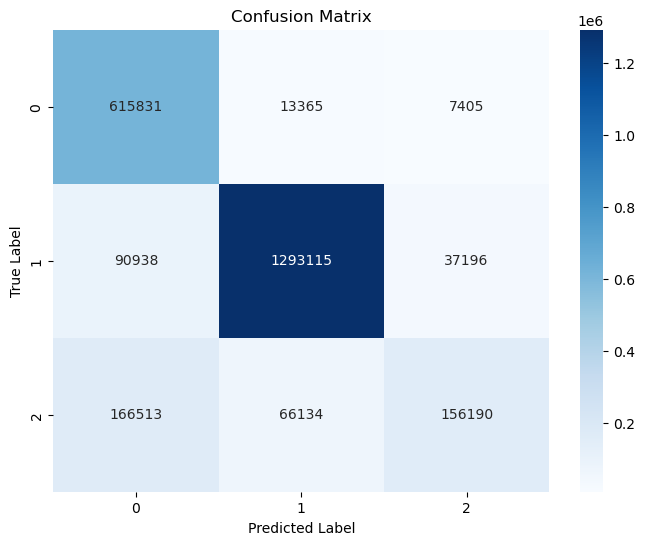

[[ 615831   13365    7405]
 [  90938 1293115   37196]
 [ 166513   66134  156190]]


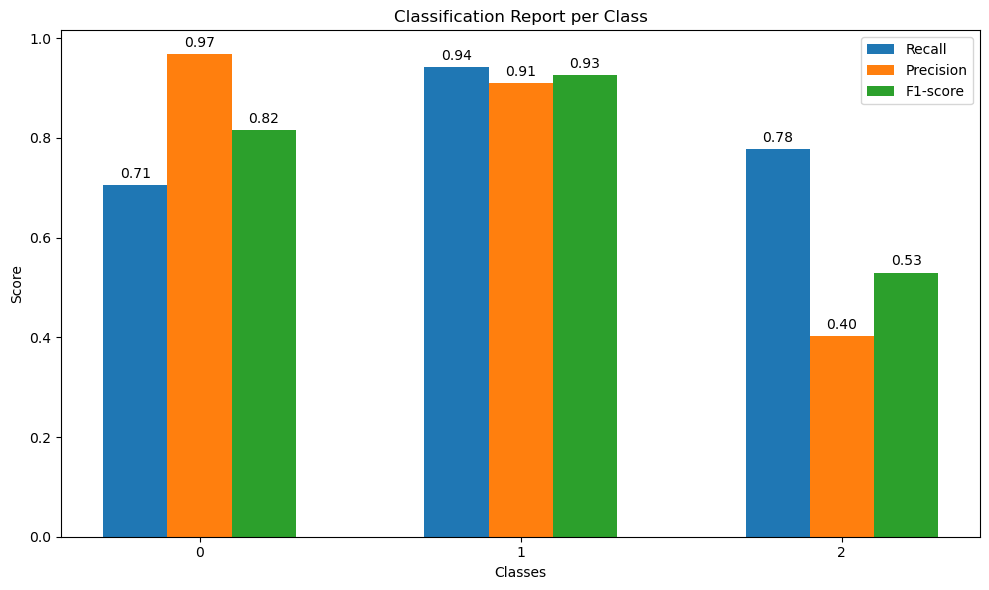

In [7]:
import numpy as np
from sklearn.base import clone
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# 3. Define the base models and the meta-model
base_models = [
    XGBClassifier(
    objective='multi:softmax',
        num_class=3,
        booster=('dart'),
        alpha=0.6730647547618864,
        subsample=0.42803065237564275,
        colsample_bytree=0.8565965677640711,
        max_depth=5,
        eta=0.179806132737519,
        gamma=0.8114340643087419,
        grow_policy='lossguide',
        min_child_weight=5,
        eval_metric='merror',
        random_state=42
        ),
    RandomForestClassifier(n_estimators=287, max_depth=22, min_samples_split=4, min_samples_leaf=5, random_state=42, class_weight='balanced'),
    lgb.LGBMClassifier(verbose=-1, n_estimators=441, learning_rate=0.0895186049880042, num_leaves=98, max_depth=8, 
                          min_child_samples=34, subsample=0.7024962299198043, colsample_bytree=0.8199213047640314, random_state=42, is_unbalance=True),



    DecisionTreeClassifier(max_depth=4, min_samples_leaf=819, criterion='gini', random_state=42)  # Meta-learner can be any classifier; Logistic Regression is a common choice
]
meta_model = DecisionTreeClassifier(max_depth=4, min_samples_leaf=819, criterion='gini', random_state=42) # The final model that blends them all

X_train_list = [train[x_xgb], train[x_rfc], train[x_lgbm]]
X_test_list = [test[x_xgb], test[x_rfc], test[x_lgbm]]

# ==========================================
# MANUAL STACKING FUNCTION
# ==========================================
def manual_stacking_predict(base_models, meta_model, X_train_list, y_train, X_test_list, n_splits=5):
    X_train_list = [X.to_numpy() if hasattr(X, 'to_numpy') else X for X in X_train_list]
    X_test_list = [X.to_numpy() if hasattr(X, 'to_numpy') else X for X in X_test_list]
    y_train = y_train.to_numpy() if hasattr(y_train, 'to_numpy') else y_train


    n_samples_train = X_train_list[0].shape[0]
    n_samples_test = X_test_list[0].shape[0]
    n_classes = len(np.unique(y_train))
    n_models = len(base_models)
    
    # Initialize empty arrays to hold the "meta-features" (predicted probabilities)
    # Total columns = (number of base models) * (number of classes)
    oof_features = np.zeros((n_samples_train, n_models * n_classes))
    test_preds_folds = np.zeros((n_splits, n_samples_test, n_models * n_classes))
    
    # Use Stratified K-Fold to generate out-of-fold predictions safely
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_list[0], y_train)):
        
        # Train each base model on its specific slice of this fold's training data
        for m_idx, (model, X_base_train) in enumerate(zip(base_models, X_train_list)):
            # Clone ensures we train a fresh copy of the model configuration on every fold
            fold_model = clone(model) 
            
            # Fit on fold training data
            fold_model.fit(X_base_train[train_idx], y_train[train_idx])
            
            # Calculate the feature columns index for this specific model
            col_start = m_idx * n_classes
            col_end = col_start + n_classes
            
            # 1. Populate training meta-features using the validation slice (Out-of-Fold)
            oof_features[val_idx, col_start:col_end] = fold_model.predict_proba(X_base_train[val_idx])
            
            # 2. Populate test meta-features for this fold using the test data
            X_base_test = X_test_list[m_idx]
            test_preds_folds[fold, :, col_start:col_end] = fold_model.predict_proba(X_base_test)
            
    # Average the test meta-features across all folds
    test_features = np.mean(test_preds_folds, axis=0)
    
    # 4. Train the meta-model on the out-of-fold features
    meta_model.fit(oof_features, y_train)
    
    # 5. Make final predictions on the test meta-features
    final_predictions = meta_model.predict(test_features)
    
    return final_predictions

# ==========================================
# EXECUTION
# ==========================================
stacking_preds = manual_stacking_predict(
    base_models, meta_model, X_train_list, train['Type'], X_test_list, n_splits=5
)

eval(stacking_preds, test['Type'])

In [ ]:
import numpy as np
from sklearn.base import clone
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# 3. Define the base models and the meta-model
base_models = [
    XGBClassifier(
    objective='multi:softmax',
        num_class=3,
        booster=('dart'),
        alpha=0.6730647547618864,
        subsample=0.42803065237564275,
        colsample_bytree=0.8565965677640711,
        max_depth=5,
        eta=0.179806132737519,
        gamma=0.8114340643087419,
        grow_policy='lossguide',
        min_child_weight=5,
        eval_metric='merror',
        random_state=42
        ),
    RandomForestClassifier(n_estimators=287, max_depth=22, min_samples_split=4, min_samples_leaf=5, random_state=42, class_weight='balanced'),
    lgb.LGBMClassifier(verbose=-1, n_estimators=441, learning_rate=0.0895186049880042, num_leaves=98, max_depth=8, 
                          min_child_samples=34, subsample=0.7024962299198043, colsample_bytree=0.8199213047640314, random_state=42, is_unbalance=True),



    KNeighborsClassifier(n_neighbors=2, weights='distance', algorithm='brute', leaf_size=77, p=2, metric='manhattan', n_jobs=1)
]
meta_model = KNeighborsClassifier(n_neighbors=2, weights='distance', algorithm='brute', leaf_size=77, p=2, metric='manhattan', n_jobs=1)

X_train_list = [train[x_xgb], train[x_rfc], train[x_lgbm]]
X_test_list = [test[x_xgb], test[x_rfc], test[x_lgbm]]

# ==========================================
# MANUAL STACKING FUNCTION
# ==========================================
def manual_stacking_predict(base_models, meta_model, X_train_list, y_train, X_test_list, n_splits=5):
    X_train_list = [X.to_numpy() if hasattr(X, 'to_numpy') else X for X in X_train_list]
    X_test_list = [X.to_numpy() if hasattr(X, 'to_numpy') else X for X in X_test_list]
    y_train = y_train.to_numpy() if hasattr(y_train, 'to_numpy') else y_train


    n_samples_train = X_train_list[0].shape[0]
    n_samples_test = X_test_list[0].shape[0]
    n_classes = len(np.unique(y_train))
    n_models = len(base_models)
    
    # Initialize empty arrays to hold the "meta-features" (predicted probabilities)
    # Total columns = (number of base models) * (number of classes)
    oof_features = np.zeros((n_samples_train, n_models * n_classes))
    test_preds_folds = np.zeros((n_splits, n_samples_test, n_models * n_classes))
    
    # Use Stratified K-Fold to generate out-of-fold predictions safely
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_list[0], y_train)):
        
        # Train each base model on its specific slice of this fold's training data
        for m_idx, (model, X_base_train) in enumerate(zip(base_models, X_train_list)):
            # Clone ensures we train a fresh copy of the model configuration on every fold
            fold_model = clone(model) 
            
            # Fit on fold training data
            fold_model.fit(X_base_train[train_idx], y_train[train_idx])
            
            # Calculate the feature columns index for this specific model
            col_start = m_idx * n_classes
            col_end = col_start + n_classes
            
            # 1. Populate training meta-features using the validation slice (Out-of-Fold)
            oof_features[val_idx, col_start:col_end] = fold_model.predict_proba(X_base_train[val_idx])
            
            # 2. Populate test meta-features for this fold using the test data
            X_base_test = X_test_list[m_idx]
            test_preds_folds[fold, :, col_start:col_end] = fold_model.predict_proba(X_base_test)
            
    # Average the test meta-features across all folds
    test_features = np.mean(test_preds_folds, axis=0)
    
    # 4. Train the meta-model on the out-of-fold features
    meta_model.fit(oof_features, y_train)
    
    # 5. Make final predictions on the test meta-features
    final_predictions = meta_model.predict(test_features)
    
    return final_predictions

# ==========================================
# EXECUTION
# ==========================================
stacking_preds = manual_stacking_predict(
    base_models, meta_model, X_train_list, train['Type'], X_test_list, n_splits=5
)

eval(stacking_preds, test['Type'])

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import xgboost as xgb

xgb_clf = XGBClassifier(
objective='multi:softmax',
    num_class=3,
    booster=('dart'),
    alpha=0.6730647547618864,
    subsample=0.42803065237564275,
    colsample_bytree=0.8565965677640711,
    max_depth=5,
    eta=0.179806132737519,
    gamma=0.8114340643087419,
    grow_policy='lossguide',
    min_child_weight=5,
    eval_metric='merror',
    random_state=42
    )
rf_clf = RandomForestClassifier(n_estimators=287, max_depth=22, min_samples_split=4, min_samples_leaf=5, random_state=42, class_weight='balanced')
lgbm_clf = lgb.LGBMClassifier(verbose=-1, n_estimators=441, learning_rate=0.0895186049880042, num_leaves=98, max_depth=8, 
                        min_child_samples=34, subsample=0.7024962299198043, colsample_bytree=0.8199213047640314, random_state=42, is_unbalance=True)


train["rf_pred"] = rf_clf.fit(train[x_rfc], train['Type']).predict_proba(train[x_rfc])[:, 1]
train["lgbm_pred"] = lgbm_clf.fit(train[x_lgbm], train['Type']).predict_proba(train[x_lgbm])[:, 1]
train["xgb_pred"] = xgb_clf.fit(train[x_xgb], train['Type']).predict_proba(train[x_xgb])[:, 1]

test["rf_pred"] = rf_clf.predict_proba(test[x_rfc])[:, 1]
test["lgbm_pred"] = lgbm_clf.predict_proba(test[x_lgbm])[:, 1]
test["xgb_pred"] = xgb_clf.predict_proba(test[x_xgb])[:, 1]

x_cols_extended = ["rf_pred", "lgbm_pred", "xgb_pred"]

In [ ]:
# Optuna hyperparameter optimization for KNN
import optuna
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

def objective(trial):
    params = {'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss']),
        'max_depth': trial.suggest_int('max_depth', 1, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 100),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 50),
        'class_weight': 'balanced', # Keep this fixed for imbalance!
        'random_state': 42}

    knn = DecisionTreeClassifier(**params)
    #knn = GaussianNB(**params, random_state=42)

    knn.fit(train[x_cols_extended], train["Type"])
    y_pred = knn.predict(test[x_cols_extended])
    return f1_score(test["Type"], y_pred, average="macro")

if __name__ == "__main__":
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=50, show_progress_bar=True)

    print("Best hyperparameters:", study.best_params)
    print("Best f1 on validation:", study.best_value)

    # Train best model on train and evaluate on test
    best_knn = DecisionTreeClassifier(**study.best_params)
    best_knn.fit(train[x_cols_extended], train["Type"])
    y_test = best_knn.predict(test[x_cols_extended])
    test_f1 = f1_score(test["Type"], y_test, average="macro")
    print(f"Test f1 of best KNN: {test_f1:.4f}")

    # Optional visualization
    try:
        optuna.visualization.plot_optimization_history(study).show()
        optuna.visualization.plot_param_importances(study).show()
    except Exception:
        pass

    eval(y_test, test['Type'])

In [ ]:
import numpy as np
from sklearn.base import clone
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# 3. Define the base models and the meta-model
base_models = [
    XGBClassifier(
    objective='multi:softmax',
        num_class=3,
        booster=('dart'),
        alpha=0.6730647547618864,
        subsample=0.42803065237564275,
        colsample_bytree=0.8565965677640711,
        max_depth=5,
        eta=0.179806132737519,
        gamma=0.8114340643087419,
        grow_policy='lossguide',
        min_child_weight=5,
        eval_metric='merror',
        random_state=42
        ),
    RandomForestClassifier(n_estimators=287, max_depth=22, min_samples_split=4, min_samples_leaf=5, random_state=42, class_weight='balanced'),
    lgb.LGBMClassifier(verbose=-1, n_estimators=441, learning_rate=0.0895186049880042, num_leaves=98, max_depth=8, 
                          min_child_samples=34, subsample=0.7024962299198043, colsample_bytree=0.8199213047640314, random_state=42, is_unbalance=True),


#{'criterion': 'entropy', 'max_depth': 1, 'min_samples_split': 33, 'min_samples_leaf': 35}
    DecisionTreeClassifier(max_depth=1, min_samples_leaf=35, criterion='entropy', min_samples_split=33, random_state=42)  # Meta-learner can be any classifier; Logistic Regression is a common choice
]
meta_model = DecisionTreeClassifier(max_depth=1, min_samples_leaf=35, criterion='entropy', min_samples_split=33, random_state=42) # The final model that blends them all

X_train_list = [train[x_xgb], train[x_rfc], train[x_lgbm]]
X_test_list = [test[x_xgb], test[x_rfc], test[x_lgbm]]

# ==========================================
# MANUAL STACKING FUNCTION
# ==========================================
def manual_stacking_predict(base_models, meta_model, X_train_list, y_train, X_test_list, n_splits=5):
    X_train_list = [X.to_numpy() if hasattr(X, 'to_numpy') else X for X in X_train_list]
    X_test_list = [X.to_numpy() if hasattr(X, 'to_numpy') else X for X in X_test_list]
    y_train = y_train.to_numpy() if hasattr(y_train, 'to_numpy') else y_train


    n_samples_train = X_train_list[0].shape[0]
    n_samples_test = X_test_list[0].shape[0]
    n_classes = len(np.unique(y_train))
    n_models = len(base_models)
    
    # Initialize empty arrays to hold the "meta-features" (predicted probabilities)
    # Total columns = (number of base models) * (number of classes)
    oof_features = np.zeros((n_samples_train, n_models * n_classes))
    test_preds_folds = np.zeros((n_splits, n_samples_test, n_models * n_classes))
    
    # Use Stratified K-Fold to generate out-of-fold predictions safely
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_list[0], y_train)):
        
        # Train each base model on its specific slice of this fold's training data
        for m_idx, (model, X_base_train) in enumerate(zip(base_models, X_train_list)):
            # Clone ensures we train a fresh copy of the model configuration on every fold
            fold_model = clone(model) 
            
            # Fit on fold training data
            fold_model.fit(X_base_train[train_idx], y_train[train_idx])
            
            # Calculate the feature columns index for this specific model
            col_start = m_idx * n_classes
            col_end = col_start + n_classes
            
            # 1. Populate training meta-features using the validation slice (Out-of-Fold)
            oof_features[val_idx, col_start:col_end] = fold_model.predict_proba(X_base_train[val_idx])
            
            # 2. Populate test meta-features for this fold using the test data
            X_base_test = X_test_list[m_idx]
            test_preds_folds[fold, :, col_start:col_end] = fold_model.predict_proba(X_base_test)
            
    # Average the test meta-features across all folds
    test_features = np.mean(test_preds_folds, axis=0)
    
    # 4. Train the meta-model on the out-of-fold features
    meta_model.fit(oof_features, y_train)
    
    # 5. Make final predictions on the test meta-features
    final_predictions = meta_model.predict(test_features)
    
    return final_predictions

# ==========================================
# EXECUTION
# ==========================================
stacking_preds = manual_stacking_predict(
    base_models, meta_model, X_train_list, train['Type'], X_test_list, n_splits=5
)

eval(stacking_preds, test['Type'])

In [ ]:
# Optuna hyperparameter optimization for KNN
import optuna
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

def objective(trial):
    params = {
        # Test odd numbers between 3 and 31
        'n_neighbors': trial.suggest_int('n_neighbors', 1, 31),
        'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
        'metric': trial.suggest_categorical('metric', ['euclidean', 'manhattan']),
        # algorithm='auto' can be slow; 'ball_tree' is usually fastest for tabular data
        'algorithm': 'ball_tree', 
        'n_jobs': -1 # Use all CPU cores
    }

    knn = KNeighborsClassifier(**params)
    #knn = GaussianNB(**params, random_state=42)

    knn.fit(train[x_cols_extended], train["Type"])
    y_pred = knn.predict(test[x_cols_extended])
    return f1_score(test["Type"], y_pred, average="macro")

if __name__ == "__main__":
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=50, show_progress_bar=True)

    print("Best hyperparameters:", study.best_params)
    print("Best f1 on validation:", study.best_value)

    # Train best model on train and evaluate on test
    best_knn = KNeighborsClassifier(**study.best_params)
    best_knn.fit(train[x_cols_extended], train["Type"])
    y_test = best_knn.predict(test[x_cols_extended])
    test_f1 = f1_score(test["Type"], y_test, average="macro")
    print(f"Test f1 of best KNN: {test_f1:.4f}")

    # Optional visualization
    try:
        optuna.visualization.plot_optimization_history(study).show()
        optuna.visualization.plot_param_importances(study).show()
    except Exception:
        pass

    eval(y_test, test['Type'])

In [ ]:
import numpy as np
from sklearn.base import clone
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# 3. Define the base models and the meta-model
base_models = [
    XGBClassifier(
    objective='multi:softmax',
        num_class=3,
        booster=('dart'),
        alpha=0.6730647547618864,
        subsample=0.42803065237564275,
        colsample_bytree=0.8565965677640711,
        max_depth=5,
        eta=0.179806132737519,
        gamma=0.8114340643087419,
        grow_policy='lossguide',
        min_child_weight=5,
        eval_metric='merror',
        random_state=42
        ),
    RandomForestClassifier(n_estimators=287, max_depth=22, min_samples_split=4, min_samples_leaf=5, random_state=42, class_weight='balanced'),
    lgb.LGBMClassifier(verbose=-1, n_estimators=441, learning_rate=0.0895186049880042, num_leaves=98, max_depth=8, 
                          min_child_samples=34, subsample=0.7024962299198043, colsample_bytree=0.8199213047640314, random_state=42, is_unbalance=True),



    KNeighborsClassifier(n_neighbors=2, weights='distance', algorithm='brute', leaf_size=77, p=2, metric='manhattan', n_jobs=1)
]
meta_model = KNeighborsClassifier(n_neighbors=2, weights='distance', algorithm='brute', leaf_size=77, p=2, metric='manhattan', n_jobs=1)

X_train_list = [train[x_xgb], train[x_rfc], train[x_lgbm]]
X_test_list = [test[x_xgb], test[x_rfc], test[x_lgbm]]

# ==========================================
# MANUAL STACKING FUNCTION
# ==========================================
def manual_stacking_predict(base_models, meta_model, X_train_list, y_train, X_test_list, n_splits=5):
    X_train_list = [X.to_numpy() if hasattr(X, 'to_numpy') else X for X in X_train_list]
    X_test_list = [X.to_numpy() if hasattr(X, 'to_numpy') else X for X in X_test_list]
    y_train = y_train.to_numpy() if hasattr(y_train, 'to_numpy') else y_train


    n_samples_train = X_train_list[0].shape[0]
    n_samples_test = X_test_list[0].shape[0]
    n_classes = len(np.unique(y_train))
    n_models = len(base_models)
    
    # Initialize empty arrays to hold the "meta-features" (predicted probabilities)
    # Total columns = (number of base models) * (number of classes)
    oof_features = np.zeros((n_samples_train, n_models * n_classes))
    test_preds_folds = np.zeros((n_splits, n_samples_test, n_models * n_classes))
    
    # Use Stratified K-Fold to generate out-of-fold predictions safely
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_list[0], y_train)):
        
        # Train each base model on its specific slice of this fold's training data
        for m_idx, (model, X_base_train) in enumerate(zip(base_models, X_train_list)):
            # Clone ensures we train a fresh copy of the model configuration on every fold
            fold_model = clone(model) 
            
            # Fit on fold training data
            fold_model.fit(X_base_train[train_idx], y_train[train_idx])
            
            # Calculate the feature columns index for this specific model
            col_start = m_idx * n_classes
            col_end = col_start + n_classes
            
            # 1. Populate training meta-features using the validation slice (Out-of-Fold)
            oof_features[val_idx, col_start:col_end] = fold_model.predict_proba(X_base_train[val_idx])
            
            # 2. Populate test meta-features for this fold using the test data
            X_base_test = X_test_list[m_idx]
            test_preds_folds[fold, :, col_start:col_end] = fold_model.predict_proba(X_base_test)
            
    # Average the test meta-features across all folds
    test_features = np.mean(test_preds_folds, axis=0)
    
    # 4. Train the meta-model on the out-of-fold features
    meta_model.fit(oof_features, y_train)
    
    # 5. Make final predictions on the test meta-features
    final_predictions = meta_model.predict(test_features)
    
    return final_predictions

# ==========================================
# EXECUTION
# ==========================================
stacking_preds = manual_stacking_predict(
    base_models, meta_model, X_train_list, train['Type'], X_test_list, n_splits=5
)

eval(stacking_preds, test['Type'])

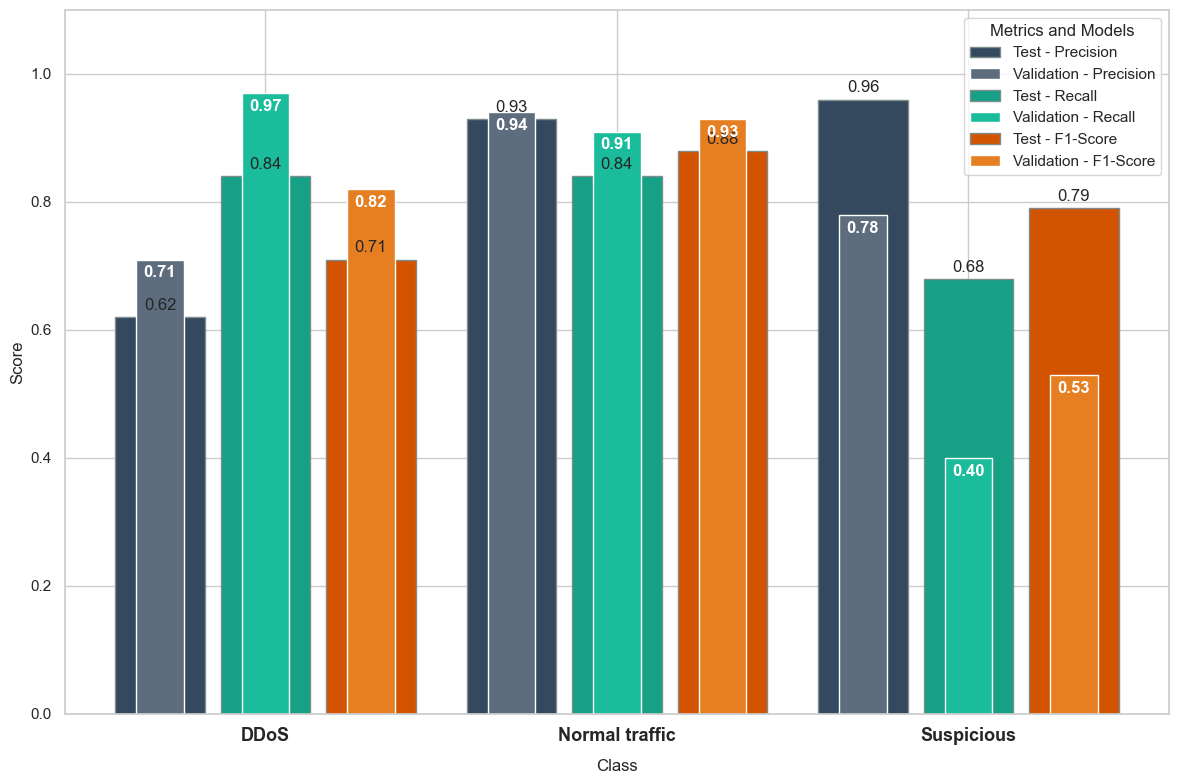

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Adatok betöltése
data = {
    'Class': ['DDoS', 'DDoS', 'DDoS', 'Normal traffic', 'Normal traffic', 'Normal traffic', 'Suspicious', 'Suspicious', 'Suspicious'],
    'Metric': ['Precision', 'Recall', 'F1-Score'] * 3,
    'Model_1_Score': [0.62, 0.84, 0.71, 0.93, 0.84, 0.88, 0.96, 0.68, 0.79],
    'Model_2_Score': [0.71, 0.97, 0.82, 0.94, 0.91, 0.93, 0.78, 0.40, 0.53]
}
df = pd.DataFrame(data)

# Sorrendbe rendezzük a biztonság kedvéért
df_grouped = df.groupby(['Class', 'Metric']).mean().reset_index()

# 2. Pozíciók és paraméterek pontos beállítása 3 metrikához
classes = ['DDoS', 'Normal traffic', 'Suspicious']
metrics = ['Precision', 'Recall', 'F1-Score']

x_indices = np.arange(len(classes)) 
group_width = 0.3  # Kicsit növelve a szélességet a jobb láthatóságért

# Színpaletta szótár (Sötétebb = Model 1, Világosabb = Model 2)
colors = {
    'Precision': ('#34495E', '#5D6D7E'),  # Grafitszürke árnyalatok
    'Recall':    ('#16A085', '#1ABC9C'),  # Türkizzöld árnyalatok
    'F1-Score':  ('#D35400', '#E67E22')   # Narancs árnyalatok
}

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 8))

# Végigmegyünk a 3 metrikán
for i, metric in enumerate(metrics):
    # TRÜKK: (i - 1) biztosítja, hogy a 3 oszlop [-1, 0, 1] eltolást kapjon, 
    # így a középső (i=1, Recall) pontosan az X-tengely felirat közepére esik!
    x_pos = x_indices + (i - 1) * group_width
    
    metric_data = df_grouped[df_grouped['Metric'] == metric].set_index('Class').reindex(classes).reset_index()
    
    color_m1, color_m2 = colors[metric]
    
    # ---- NESTED OSZLOPOK RAJZOLÁSA ----
    # 1. Model 1 (Szélesebb háttér oszlop)
    rects1 = ax.bar(x_pos, metric_data['Model_1_Score'], width=group_width*0.85, 
                    color=color_m1, edgecolor='#7F8C8D', label=f'Test - {metric}')
    
    # 2. Model 2 (Keskenyebb előtér oszlop)
    rects2 = ax.bar(x_pos, metric_data['Model_2_Score'], width=group_width*0.45, 
                    color=color_m2, edgecolor='white', label=f'Validation - {metric}')
    
    # Érték címkék hozzáadása és pozícionálása
    for r1, r2 in zip(rects1, rects2):
        h1 = r1.get_height()
        h2 = r2.get_height()
        
        # Külső címke (Model 1) - Mindig a magasabb érték szerint igazítva, hogy ne ütközzön
        ax.annotate(f'{h1:.2f}', xy=(r1.get_x() + r1.get_width()/2, h1),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=12)
        
        # Belső címke (Model 2) - Beágyazva az oszlop belsejébe
        ax.annotate(f'{h2:.2f}', xy=(r2.get_x() + r2.get_width()/2, h2),
                    xytext=(0, -15), textcoords="offset points", ha='center', va='bottom', 
                    fontsize=12, color='white', weight='bold')

# 3. Grafikon finomhangolása és igazítása
ax.set_xticks(x_indices)
ax.set_xticklabels(classes, fontsize=13, weight='bold') # Szép hangsúlyos alsó címkék
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=12)
ax.set_xlabel('Class', fontsize=12, labelpad=10)

# Legenda elhelyezése
ax.legend(title="Metrics and Models", loc='best', bbox_to_anchor=(1, 1), frameon=True)

plt.tight_layout()
plt.savefig('data/figures/final.png', dpi=600, bbox_inches='tight')
plt.show()